In [64]:
import pandas as pd
import numpy as np
data=pd.read_csv("/content/HR_Data_MNC_Data Science Lovers.csv")

In [65]:
df=pd.DataFrame(data)
df.head(3)


,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084


Data Cleaning

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Unnamed: 0          int64 
 1   Employee_ID         object
 2   Full_Name           object
 3   Department          object
 4   Job_Title           object
 5   Hire_Date           object
 6   Location            object
 7   Performance_Rating  int64 
 8   Experience_Years    int64 
 9   Status              object
 10  Work_Mode           object
 11  Salary_INR          int64 
dtypes: int64(4), object(8)
memory usage: 183.1+ MB


In [67]:
#Identifying null values
df.isnull().sum()

,0
Unnamed: 0,0
Employee_ID,0
Full_Name,0
Department,0
Job_Title,0
Hire_Date,0
Location,0
Performance_Rating,0
Experience_Years,0
Status,0


In [68]:
#Iddentifying Duplicate Values
df.duplicated().sum()
#df.drop_duplicates()

np.int64(0)

In [69]:
#conversion into proper datetime
df['Hire_Date']=pd.to_datetime(df['Hire_Date'])
df['Tenure Year']=pd.Timestamp('today')-df['Hire_Date']
df['Tenure Year']=df['Tenure Year'].dt.days/365
df.head()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure Year
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,14.556164
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,7.991781
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,2.939726
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,2.375342
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,1.213699


In [70]:
df[df['Experience_Years']>df['Tenure Year']]

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure Year


In [71]:
#standardizing text values
df['Department']=df['Department'].str.strip()
df['Job_Title']=df['Job_Title'].str.strip()
df.head()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure Year
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,14.556164
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,7.991781
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,2.939726
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,2.375342
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,1.213699


In [72]:
df[df['Salary_INR']<0]

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure Year


In [73]:
#identifying outliers
Q1=np.percentile(df['Salary_INR'],25)
Q3=np.percentile(df['Salary_INR'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Salary_INR']<lower_bound) | (df['Salary_INR']>upper_bound)]
outliers.head()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure Year
24,24,EMP0000025,Amanda Miller,IT,IT Manager,2021-07-31,"Tammyview, Barbados",2,4,Active,Remote,2153098,4.575342
32,32,EMP0000033,Cristian Thomas,IT,IT Manager,2021-02-14,"North Markbury, San Marino",3,4,Active,Remote,2408177,5.032877
34,34,EMP0000035,Kathleen Shields,IT,IT Manager,2023-07-26,"North Brianmouth, Zambia",1,2,Retired,On-site,2615626,2.589041
103,103,EMP0000104,Tamara Wilson,Finance,Finance Manager,2023-01-10,"South Stevenmouth, South Georgia and the South...",2,2,Resigned,On-site,2118072,3.128767
143,143,EMP0000144,Jane Mcintyre,IT,IT Manager,2024-09-16,"Housemouth, Guam",4,0,Active,On-site,2194883,1.443836


Exploratory Data Analysis

In [75]:
#calculating avg salary per department
df.groupby('Department')['Salary_INR'].agg(np.mean)

/tmp/ipython-input-3768974276.py:2: FutureWarning: The provided callable <function mean at 0x788065a51a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.groupby('Department')['Salary_INR'].agg(np.mean)


,Salary_INR
Department,
Finance,9.404117e+05
HR,7.438536e+05
IT,1.129858e+06
Marketing,7.699362e+05
Operations,7.546263e+05
R&D,8.003772e+05
Sales,7.929579e+05


In [76]:
mean= np.mean(df['Salary_INR'])
print(mean)
median= np.median(df['Salary_INR'])
print(median)
std= np.std(df['Salary_INR'])
print(std)

896887.7556635
811026.5
402610.20378516125


In [77]:
#employee count by work mode
df['Work_Mode'].value_counts()

,count
Work_Mode,
On-site,1199109
Remote,800891


In [78]:
#top 5 location havinh max no. of employees
df['Location'].value_counts().head(5)

,count
Location,
"Lake Michael, Congo",20
"New Christopher, Congo",19
"East Michael, Congo",17
"West Michael, Uzbekistan",16
"East David, Congo",16


In [79]:
df.groupby(['Department','Status']).size()

Department  Status    
Finance     Active        139716
            Resigned       40238
            Retired         9931
            Terminated      9988
HR          Active        111578
            Resigned       31736
            Retired         7944
            Terminated      7861
IT          Active        421333
            Resigned      119852
            Retired        29976
            Terminated     29881
Marketing   Active        168316
            Resigned       47793
            Retired        11928
            Terminated     12044
Operations  Active        210818
            Resigned       59397
            Retired        14996
            Terminated     14884
R&D         Active         69859
            Resigned       19919
            Retired         4983
            Terminated      4998
Sales       Active        279938
            Resigned       79725
            Retired        20154
            Terminated     20214
dtype: int64

In [80]:
df['Experience_Years'].corr(df['Salary_INR'])

np.float64(0.000796123144326114)

In [81]:
df[df['Performance_Rating'] <= 2]

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure Year
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,7.991781
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,2.939726
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,2.375342
6,6,EMP0000007,Julie Wright,Finance,Finance Manager,2016-04-04,"Karenfort, South Africa",2,9,Active,On-site,1383891,9.901370
7,7,EMP0000008,Scott Wilson,Sales,Account Manager,2020-04-04,"Moniqueview, British Virgin Islands",2,5,Active,Remote,423091,5.898630
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999990,1999990,EMP1999991,Frank Ware,R&D,Product Developer,2015-11-16,"West Jaketon, Malta",2,9,Active,Remote,1178437,10.284932
1999991,1999991,EMP1999992,Donald Brooks,Marketing,SEO Specialist,2014-08-03,"Port Cameron, Switzerland",2,11,Active,On-site,999129,11.572603
1999992,1999992,EMP1999993,Phillip Small,IT,Data Analyst,2021-10-17,"Gonzalezstad, Korea",1,3,Active,On-site,957820,4.361644
1999994,1999994,EMP1999995,Mrs. Denise Jones,Sales,Sales Director,2012-02-19,"Simpsonberg, Uganda",1,13,Active,Remote,450459,14.027397


In [82]:
#department with highest average tenure
df.groupby('Department')['Tenure Year'].agg(np.mean)

/tmp/ipython-input-553944191.py:2: FutureWarning: The provided callable <function mean at 0x788065a51a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.groupby('Department')['Tenure Year'].agg(np.mean)


,Tenure Year
Department,
Finance,6.053400
HR,6.047331
IT,6.043175
Marketing,6.035073
Operations,6.044058
R&D,6.035503
Sales,6.041809


Data Visualization

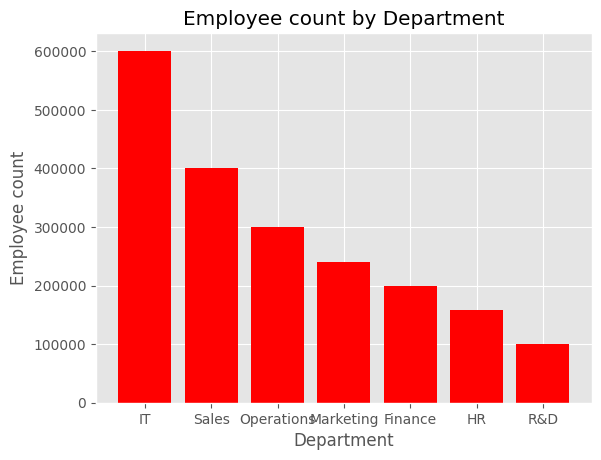

In [83]:
import matplotlib.pyplot as plt
counts=df['Department'].value_counts()
plt.bar(counts.index, counts.values, color='red')
plt.title('Employee count by Department')
plt.xlabel('Department')
plt.ylabel('Employee count')
plt.show()

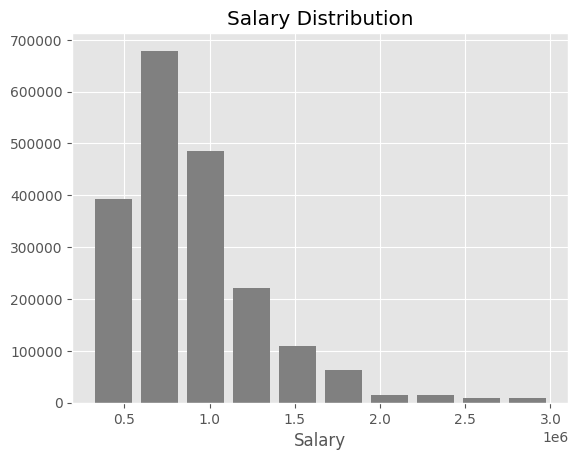

In [84]:
x=df['Salary_INR']
plt.hist(x, bins=10, histtype='bar',rwidth=0.8,color='grey')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.show()

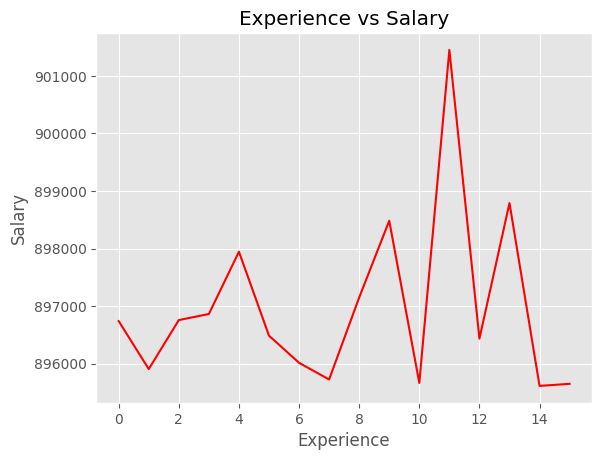

In [85]:
data=df.groupby('Experience_Years')['Salary_INR'].mean()
x=data.index
y=data.values
plt.plot(x,y,color='red')
plt.title('Experience vs Salary')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

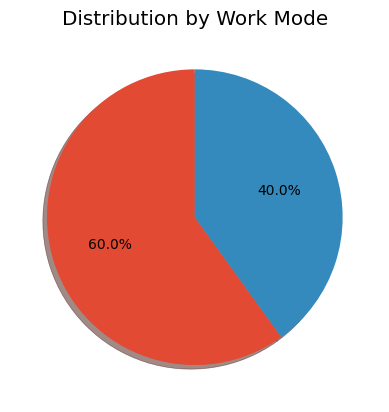

In [86]:
x=df['Work_Mode'].value_counts()
plt.pie(x,autopct='%1.1f%%',shadow=True,startangle=90)
plt.title('Distribution by Work Mode')

plt.show()

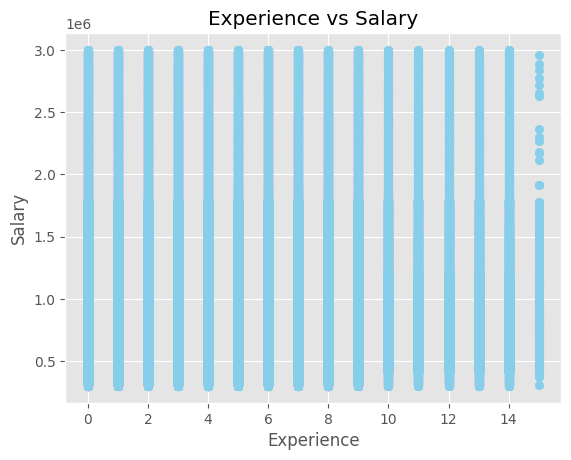

In [87]:
from matplotlib import style
x=df['Experience_Years']
y=df['Salary_INR']
style.use('ggplot')
plt.scatter(x,y,color='skyblue')
plt.title('Experience vs Salary')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()